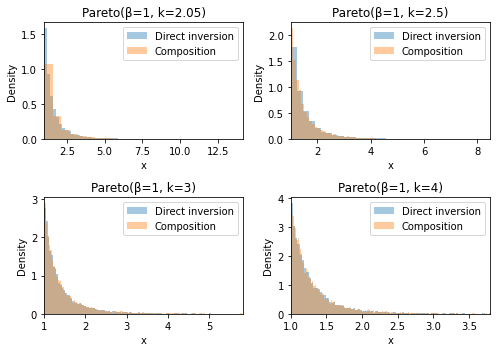


k = 2.05
Direct vs theoretical: statistic = 0.0083, p = 0.4871
Comp vs theoretical:   statistic = 0.0105, p = 0.2219
Direct vs comp:        statistic = 0.0084, p = 0.8722

k = 2.5
Direct vs theoretical: statistic = 0.0045, p = 0.9874
Comp vs theoretical:   statistic = 0.0053, p = 0.9393
Direct vs comp:        statistic = 0.0068, p = 0.9749

k = 3
Direct vs theoretical: statistic = 0.0068, p = 0.7430
Comp vs theoretical:   statistic = 0.0088, p = 0.4115
Direct vs comp:        statistic = 0.0101, p = 0.6875

k = 4
Direct vs theoretical: statistic = 0.0090, p = 0.3904
Comp vs theoretical:   statistic = 0.0080, p = 0.5364
Direct vs comp:        statistic = 0.0115, p = 0.5229


In [1]:
# Exercise 3 - Part 4

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

N = 10000
beta = 1
k_values = [2.05, 2.5, 3, 4]

X_direct = np.zeros((len(k_values), N))

# Direct inversion method for all k values
for i, k in enumerate(k_values):
    U = np.random.uniform(0, 1, size=N)
    X_direct[i, :] = beta * (U ** (-1 / k)) 


# Composition method for all k values

# Step 1: generate exponential with rate k
X_comp = np.zeros((len(k_values), N))

for i, k in enumerate(k_values):
    U_exp = np.random.uniform(0, 1, size=N)
    Y = -np.log(U_exp) / k           

# Step 2: transform exponential to Pareto
    X_comp[i, :] = beta * np.exp(Y)         



fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten() 

for idx, k in enumerate(k_values):
    x_grid = np.linspace(beta, np.percentile(X_direct[idx, :], 99.5), 500)
    pdf_pareto = k * beta**k / x_grid**(k + 1)
    ax = axes[idx]
    ax.hist(X_direct[idx, :], bins=500, density=True, alpha=0.4, label="Direct inversion")
    ax.hist(X_comp[idx, :], bins=500, density=True, alpha=0.4, label="Composition")
    #ax.plot(x_grid, pdf_pareto, 'k', linewidth=2, label="Theoretical PDF")
    ax.set_xlim(beta, np.percentile(X_direct[idx, :], 99.5))
    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.set_title(f"Pareto(β={beta}, k={k})")
    ax.legend()
    
plt.tight_layout()
#plt.savefig("pareto_comparison.png", dpi=300)
plt.show()

for idx, k in enumerate(k_values):
    ks_direct = stats.kstest(X_direct[idx, :], 'pareto', args=(k, 0, beta))
    ks_comp   = stats.kstest(X_comp[idx, :], 'pareto', args=(k, 0, beta))
    ks_between = stats.ks_2samp(X_direct[idx, :], X_comp[idx, :])

    print(f"\nk = {k}")
    print(f"Direct vs theoretical: statistic = {ks_direct.statistic:.4f}, p = {ks_direct.pvalue:.4f}")
    print(f"Comp vs theoretical:   statistic = {ks_comp.statistic:.4f}, p = {ks_comp.pvalue:.4f}")
    print(f"Direct vs comp:        statistic = {ks_between.statistic:.4f}, p = {ks_between.pvalue:.4f}")
